In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('singer_features.csv')

In [37]:
df.head()
df.shape

(3613, 17)

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["label"])
x = df.drop("label",axis = 1)

In [5]:
x.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,zcr,chroma_mean
0,-360.09933,22.019585,-72.170220,-25.820877,-28.075487,0.684296,13.991911,-6.436762,-18.203794,33.657150,-8.518291,3.718016,7.119060,2254.634880,0.099336,0.265914
1,-424.15010,26.204453,-66.430430,41.559240,3.610721,-60.740990,-20.674871,2.494788,-1.760720,25.456635,-2.758845,0.775470,12.229854,2185.109361,0.107815,0.240413
2,-464.52920,-8.834193,-26.840797,72.715360,2.219018,-42.397076,2.727844,-3.554710,-31.591190,19.704456,-18.277350,6.226011,-2.359181,2543.302266,0.098492,0.254612
3,-434.86215,52.839040,-46.433900,0.334090,-40.795803,-28.138374,24.308582,-16.651693,-17.529920,27.494417,-3.355970,2.927056,9.143897,1816.293715,0.070772,0.227547
4,-493.98175,42.129040,0.854069,16.317635,-28.028332,-19.169281,8.368003,-6.219119,-36.691353,19.811087,-19.013870,2.385262,12.418822,1778.560396,0.048666,0.189960


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 42,test_size = 0.2)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
col_names = x.columns
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train),columns=col_names)
x_test_scaled = pd.DataFrame(scaler.fit_transform(x_test),columns=col_names)

# Linear Regression - without scaling

In [8]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

In [9]:
y_pred = linear_model.predict(x_test)

In [10]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print("r2_score", r2_score(y_test,y_pred))

r2_score 0.5548229004463391


# Linear Regression - Scaling

In [11]:
linear_scaled_model = LinearRegression()
linear_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = linear_model.predict(x_test_scaled)
print("r2_score", r2_score(y_test,y_scaled_pred))  
# by this we can understand regression does not suits to given data

r2_score -30.740946308633678


# Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(solver='saga', max_iter=5000, random_state=42)
log_reg_model.fit(x_train,y_train)
y_pred = log_reg_model.predict(x_test)

accuracy_score 0.6514522821576764
precision_score 0.6577978047768956
recall_score 0.6608529858916536
f1_score 0.6545548474703711
classification report:
              precision    recall  f1-score   support

           0       0.55      0.50      0.53        42
           1       0.70      0.59      0.64        51
           2       0.47      0.45      0.46        42
           3       0.67      0.86      0.75        28
           4       0.49      0.60      0.54        35
           5       0.73      0.62      0.67        39
           6       0.69      0.73      0.71        33
           7       0.59      0.55      0.57        29
           8       0.61      0.55      0.58        40
           9       0.84      0.53      0.65        40
          10       0.81      0.81      0.81        32
          11       0.63      0.69      0.66        35
          12       0.67      0.71      0.69        28
          13       0.58      0.58      0.58        31
          14       0.67      0.72    

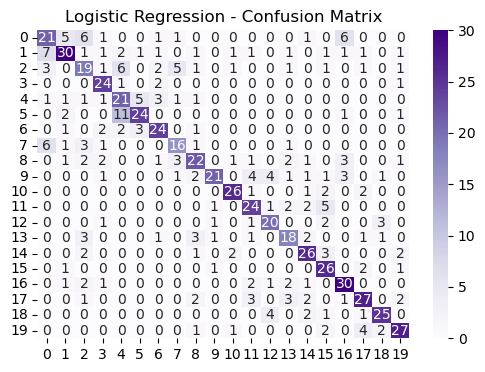

In [17]:
from sklearn.metrics import accuracy_score,classification_report,precision_score,f1_score,recall_score,confusion_matrix
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# Logistic Regression - Scaling

accuracy_score 0.7330567081604425
precision_score 0.7357182136204933
recall_score 0.7365129446668774
f1_score 0.7323141356993061
classification report:
              precision    recall  f1-score   support

           0       0.72      0.62      0.67        42
           1       0.80      0.71      0.75        51
           2       0.59      0.62      0.60        42
           3       0.76      0.79      0.77        28
           4       0.84      0.74      0.79        35
           5       0.83      0.87      0.85        39
           6       0.72      0.85      0.78        33
           7       0.71      0.69      0.70        29
           8       0.84      0.68      0.75        40
           9       0.75      0.60      0.67        40
          10       0.70      0.88      0.78        32
          11       0.79      0.77      0.78        35
          12       0.58      0.64      0.61        28
          13       0.58      0.68      0.63        31
          14       0.79      0.64    

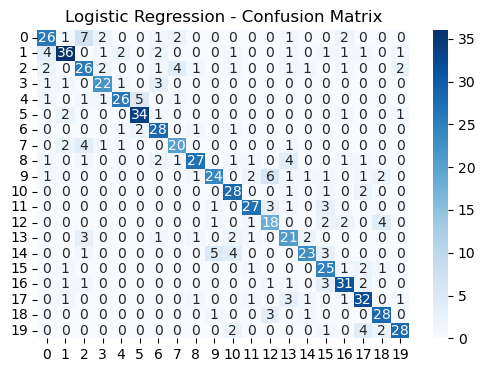

In [18]:
log_scaled_model = LogisticRegression()
log_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = log_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_scaled_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# KNN

accuracy_score 0.4384508990318119
precision_score 0.4775345176458677
recall_score 0.44090902481953653
f1_score 0.438147667901667
classification report:
              precision    recall  f1-score   support

           0       0.28      0.57      0.38        42
           1       0.36      0.41      0.38        51
           2       0.31      0.40      0.35        42
           3       0.59      0.68      0.63        28
           4       0.30      0.26      0.28        35
           5       0.63      0.56      0.59        39
           6       0.21      0.18      0.19        33
           7       0.13      0.10      0.12        29
           8       0.43      0.30      0.35        40
           9       0.50      0.55      0.52        40
          10       0.51      0.72      0.60        32
          11       0.57      0.74      0.64        35
          12       0.41      0.54      0.46        28
          13       0.37      0.42      0.39        31
          14       0.71      0.33    

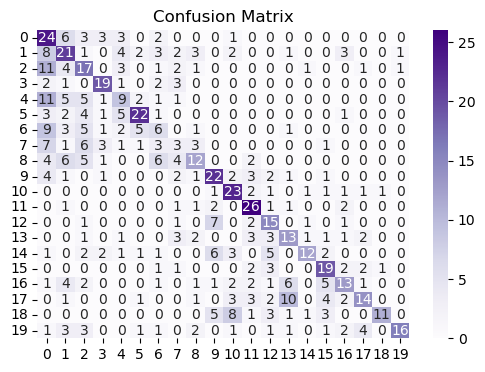

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 2)
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()

# Finding Best -k

In [20]:
accuracy = []
for i in range(2,25):
    knn_scaled_model = KNeighborsClassifier(n_neighbors = i)
    knn_scaled_model.fit(x_train_scaled,y_train)
    y_scaled_pred = knn_scaled_model.predict(x_test_scaled)
    accuracy.append(accuracy_score(y_test,y_scaled_pred))
    
#print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
# print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
# print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
# print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))

<BarContainer object of 23 artists>

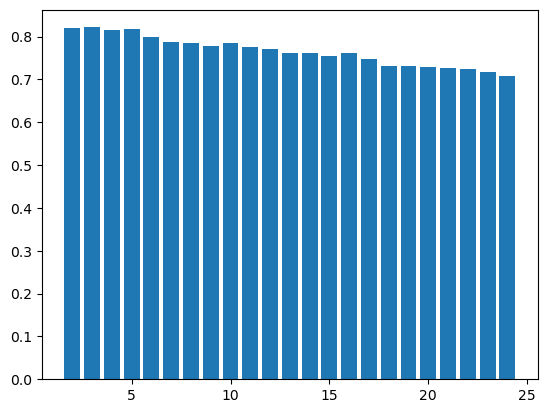

In [21]:
import matplotlib.pyplot as plt
plt.bar(range(2,25),accuracy)

# KNN - Scaling

0.8215767634854771
accuracy_score 0.8215767634854771
precision_score 0.8343808752788124
recall_score 0.8266798938036153
f1_score 0.8258357677642005
classification report:
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        42
           1       0.65      0.63      0.64        51
           2       0.76      0.81      0.78        42
           3       0.78      0.89      0.83        28
           4       0.81      0.71      0.76        35
           5       0.95      0.90      0.92        39
           6       0.71      0.82      0.76        33
           7       0.84      0.72      0.78        29
           8       0.89      0.78      0.83        40
           9       0.97      0.72      0.83        40
          10       0.97      0.91      0.94        32
          11       0.91      0.89      0.90        35
          12       0.59      0.86      0.70        28
          13       0.90      0.87      0.89        31
          14      

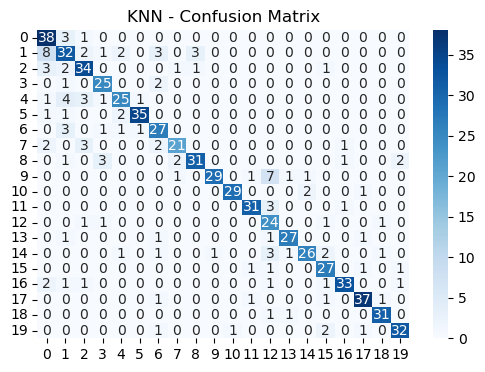

In [22]:
# since i got high accuracy at k = 2,3 i am using k =3
knn_scaled_model = KNeighborsClassifier(n_neighbors = 3)
knn_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = knn_scaled_model.predict(x_test_scaled)
print(accuracy_score(y_test,y_scaled_pred))
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_scaled_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.show()

# Decision Tree

accuracy_score 0.5560165975103735
precision_score 0.5602372314582869
recall_score 0.5627756302461937
f1_score 0.5574628339755283
classification report:
              precision    recall  f1-score   support

           0       0.58      0.50      0.54        42
           1       0.57      0.33      0.42        51
           2       0.46      0.50      0.48        42
           3       0.53      0.61      0.57        28
           4       0.53      0.54      0.54        35
           5       0.76      0.74      0.75        39
           6       0.62      0.64      0.63        33
           7       0.29      0.41      0.34        29
           8       0.40      0.42      0.41        40
           9       0.61      0.42      0.50        40
          10       0.60      0.75      0.67        32
          11       0.54      0.57      0.56        35
          12       0.62      0.64      0.63        28
          13       0.52      0.45      0.48        31
          14       0.54      0.56    

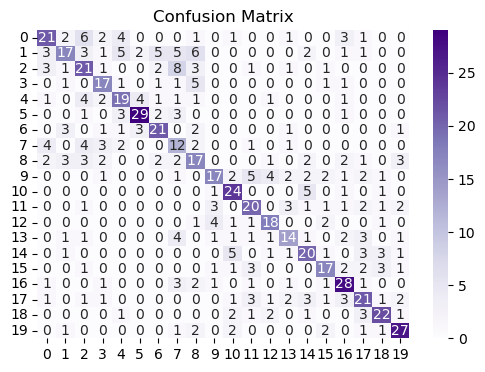

In [23]:
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier()
dtc_model.fit(x_train,y_train)
y_pred = dtc_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()

# Decision Tree - Scaling

accuracy_score 0.5311203319502075
precision_score 0.5362255311007498
recall_score 0.5364850537582895
f1_score 0.5306047534887307
classification report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.51        42
           1       0.52      0.29      0.38        51
           2       0.50      0.43      0.46        42
           3       0.56      0.64      0.60        28
           4       0.46      0.49      0.47        35
           5       0.78      0.74      0.76        39
           6       0.63      0.73      0.68        33
           7       0.28      0.38      0.32        29
           8       0.53      0.47      0.50        40
           9       0.74      0.42      0.54        40
          10       0.54      0.62      0.58        32
          11       0.47      0.60      0.53        35
          12       0.45      0.50      0.47        28
          13       0.50      0.42      0.46        31
          14       0.42      0.50    

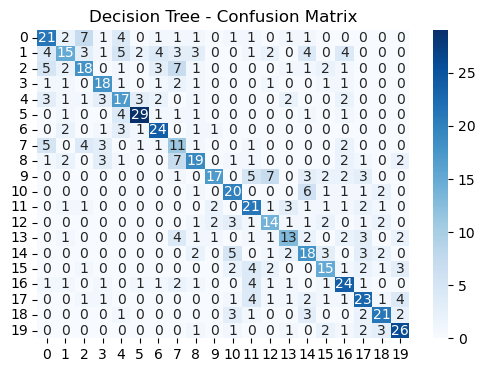

In [24]:
dtc_scaled_model=  DecisionTreeClassifier()
dtc_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = dtc_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_scaled_pred))
# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

# Random Forest

accuracy_score 0.8201936376210235
precision_score 0.8260561265476
recall_score 0.8255611895202474
f1_score 0.8222562088740059
classification report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        42
           1       0.86      0.61      0.71        51
           2       0.76      0.76      0.76        42
           3       0.83      0.89      0.86        28
           4       0.74      0.83      0.78        35
           5       0.85      0.90      0.88        39
           6       0.77      0.82      0.79        33
           7       0.70      0.66      0.68        29
           8       0.85      0.82      0.84        40
           9       0.88      0.75      0.81        40
          10       0.93      0.88      0.90        32
          11       0.94      0.86      0.90        35
          12       0.74      0.82      0.78        28
          13       0.97      0.94      0.95        31
          14       0.85      0.78      0

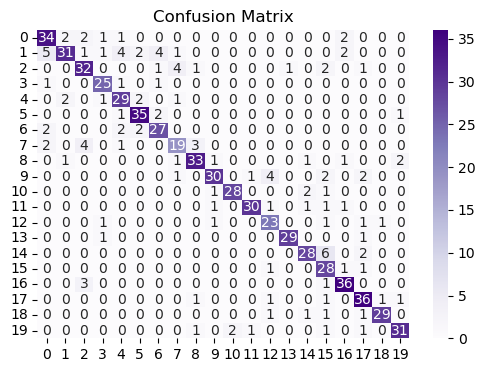

In [31]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
rfc_model = RandomForestClassifier(n_estimators=100)
rfc_model.fit(x_train, y_train)
y_pred = rfc_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()

# Random Forest scaling

accuracy_score 0.8243430152143845
precision_score 0.8293945300220191
recall_score 0.8288035996006429
f1_score 0.8260244537421929
classification report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        42
           1       0.81      0.69      0.74        51
           2       0.77      0.79      0.78        42
           3       0.83      0.86      0.84        28
           4       0.83      0.86      0.85        35
           5       0.86      0.92      0.89        39
           6       0.76      0.88      0.82        33
           7       0.77      0.69      0.73        29
           8       0.75      0.75      0.75        40
           9       0.97      0.75      0.85        40
          10       0.84      0.84      0.84        32
          11       0.97      0.89      0.93        35
          12       0.77      0.86      0.81        28
          13       0.97      0.90      0.93        31
          14       0.76      0.72    

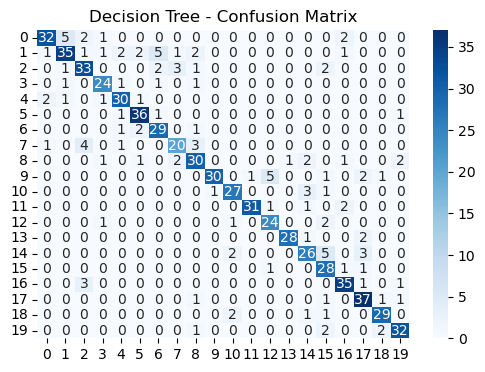

In [33]:
rfc_scaled_model=  RandomForestClassifier(n_estimators = 100)
rfc_scaled_model.fit(x_train_scaled,y_train)
y_scaled_pred = rfc_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_scaled_pred))
print('precision_score',precision_score(y_test,y_scaled_pred,average="macro"))
print('recall_score',recall_score(y_test,y_scaled_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_scaled_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_scaled_pred))
# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

# GradientBoostingClassifier

accuracy_score 0.8354080221300139
precision_score 0.8408448342875818
recall_score 0.8402734444063384
f1_score 0.8366776476735692
classification report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83        42
           1       0.84      0.73      0.78        51
           2       0.78      0.76      0.77        42
           3       0.83      0.89      0.86        28
           4       0.83      0.83      0.83        35
           5       0.88      0.90      0.89        39
           6       0.70      0.85      0.77        33
           7       0.75      0.72      0.74        29
           8       0.89      0.80      0.84        40
           9       0.93      0.70      0.80        40
          10       0.93      0.88      0.90        32
          11       0.91      0.89      0.90        35
          12       0.77      0.86      0.81        28
          13       0.93      0.90      0.92        31
          14       0.84      0.75    

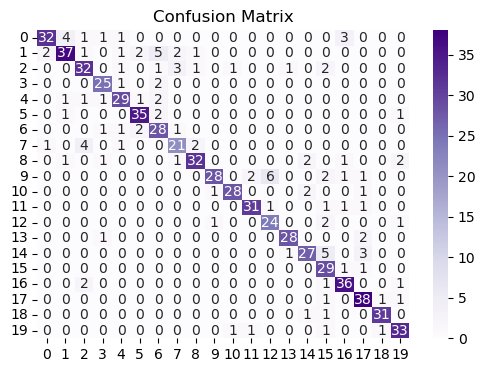

In [34]:
gbc_model = RandomForestClassifier()
gbc_model.fit(x_train, y_train)
y_pred = gbc_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()

# Gradient Boosting Classifier - Scaling

accuracy_score 0.8271092669432918
precision_score 0.8318409814188907
recall_score 0.8311962877183854
f1_score 0.8281772078227962
classification report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        42
           1       0.80      0.71      0.75        51
           2       0.80      0.79      0.80        42
           3       0.83      0.89      0.86        28
           4       0.84      0.89      0.86        35
           5       0.92      0.87      0.89        39
           6       0.78      0.88      0.83        33
           7       0.83      0.69      0.75        29
           8       0.79      0.85      0.82        40
           9       0.94      0.72      0.82        40
          10       0.87      0.84      0.86        32
          11       0.91      0.86      0.88        35
          12       0.74      0.82      0.78        28
          13       0.90      0.87      0.89        31
          14       0.81      0.69    

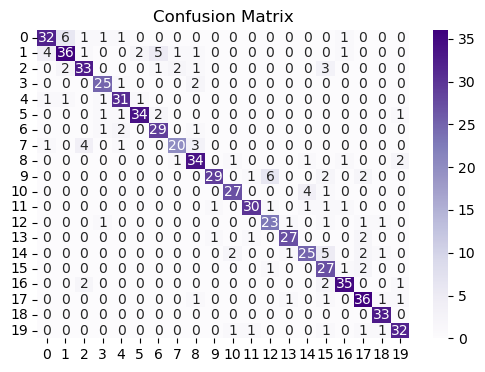

In [35]:
gbc_scaled_model = RandomForestClassifier()
gbc_scaled_model.fit(x_train_scaled, y_train)
y_pred = gbc_scaled_model.predict(x_test_scaled)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()

# SVC Classifier 

accuracy_score 0.1355463347164592
precision_score 0.15519220194621386
recall_score 0.14586735460651093
f1_score 0.10456052330371624
classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.00      0.00      0.00        51
           2       0.15      0.29      0.20        42
           3       0.62      0.54      0.58        28
           4       0.09      0.09      0.09        35
           5       0.33      0.08      0.12        39
           6       0.00      0.00      0.00        33
           7       0.06      0.34      0.10        29
           8       0.00      0.00      0.00        40
           9       0.00      0.00      0.00        40
          10       0.18      0.41      0.25        32
          11       0.00      0.00      0.00        35
          12       0.00      0.00      0.00        28
          13       0.00      0.00      0.00        31
          14       0.20      0.03 

C:\Users\NUKALA SRINU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\NUKALA SRINU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\NUKALA SRINU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\NUKALA SRI

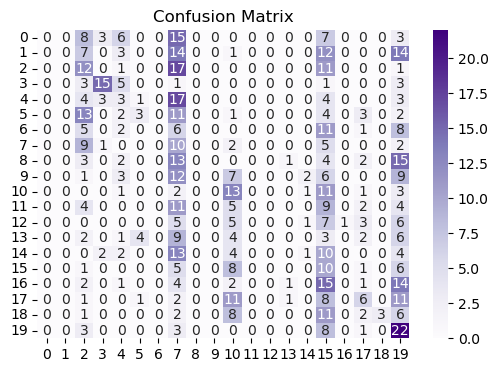

In [25]:
from sklearn.svm import SVC
svc_model = SVC() # kernel = 'RBF'
svc_model.fit(x_train, y_train)
y_pred = svc_model.predict(x_test)
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score',precision_score(y_test,y_pred,average="macro"))
print('recall_score',recall_score(y_test,y_pred,average = "macro"))
print('f1_score',f1_score(y_test,y_pred,average = "macro"))
print("classification report:")
print(classification_report(y_test,y_pred))
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix')
plt.show()
# performs worst without scaling

# SVC Classifier - Scaling

# svc - linear

--- SVC Classifier ---
Accuracy:  0.8271
Precision: 0.8298
Recall:    0.8249
F1 Score:  0.8256
classification report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        42
           1       0.86      0.84      0.85        51
           2       0.73      0.86      0.79        42
           3       0.83      0.86      0.84        28
           4       0.84      0.74      0.79        35
           5       0.90      0.90      0.90        39
           6       0.93      0.85      0.89        33
           7       0.82      0.79      0.81        29
           8       0.82      0.90      0.86        40
           9       0.89      0.82      0.86        40
          10       0.93      0.88      0.90        32
          11       0.79      0.77      0.78        35
          12       0.73      0.68      0.70        28
          13       0.67      0.77      0.72        31
          14       0.92      0.92      0.92        36
          15     

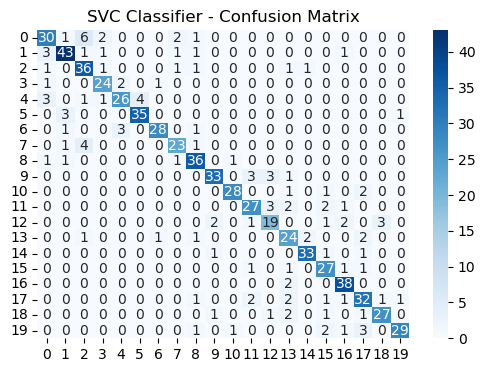

In [41]:
from sklearn.pipeline import make_pipeline
# Train
svc_scaled_linear_model = make_pipeline(StandardScaler(), SVC(kernel='linear'))
svc_scaled_poly_model = make_pipeline(StandardScaler(), SVC(kernel='poly'))
svc_scaled_rbf_model = make_pipeline(StandardScaler(), SVC(probability=True))
svc_scaled_linear_model.fit(x_train, y_train)
svc_scaled_poly_model.fit(x_train, y_train)
svc_scaled_rbf_model.fit(x_train, y_train)

y_scaled_pred = svc_scaled_linear_model.predict(x_test)
# Metrics
print("--- SVC Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_scaled_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_scaled_pred, average='macro'):.4f}")

# Classification Report
print("classification report:")
print(classification_report(y_test,y_scaled_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SVC Classifier - Confusion Matrix')
plt.show()

# svc - poly

--- SVC Classifier ---
Accuracy:  0.8299
Precision: 0.8590
Recall:    0.8325
F1 Score:  0.8343
classification report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        42
           1       0.84      0.61      0.70        51
           2       0.87      0.81      0.84        42
           3       1.00      0.82      0.90        28
           4       0.80      0.80      0.80        35
           5       0.97      0.92      0.95        39
           6       0.65      0.97      0.78        33
           7       0.89      0.59      0.71        29
           8       0.78      0.88      0.82        40
           9       0.91      0.72      0.81        40
          10       1.00      0.84      0.92        32
          11       0.91      0.86      0.88        35
          12       0.81      0.79      0.80        28
          13       1.00      0.87      0.93        31
          14       0.93      0.72      0.81        36
          15     

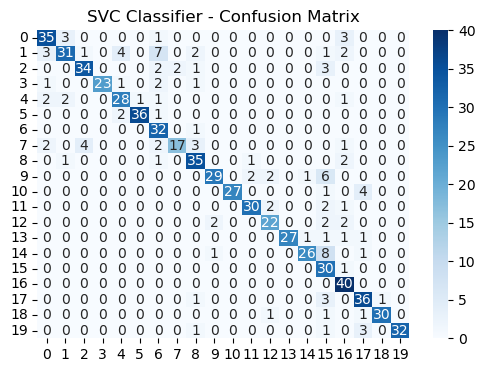

In [43]:
y_scaled_pred = svc_scaled_poly_model.predict(x_test)
# Metrics
print("--- SVC Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_scaled_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_scaled_pred, average='macro'):.4f}")

# Classification Report
print("classification report:")
print(classification_report(y_test,y_scaled_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SVC Classifier - Confusion Matrix')
plt.show()

# svc - rbf

--- SVC Classifier ---
Accuracy:  0.8700
Precision: 0.8755
Recall:    0.8734
F1 Score:  0.8717
classification report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        42
           1       0.88      0.71      0.78        51
           2       0.91      0.93      0.92        42
           3       0.92      0.86      0.89        28
           4       0.85      0.80      0.82        35
           5       0.86      0.95      0.90        39
           6       0.81      0.88      0.84        33
           7       0.86      0.83      0.84        29
           8       0.80      0.90      0.85        40
           9       0.97      0.80      0.88        40
          10       0.97      0.88      0.92        32
          11       0.89      0.89      0.89        35
          12       0.77      0.86      0.81        28
          13       0.93      0.90      0.92        31
          14       0.91      0.89      0.90        36
          15     

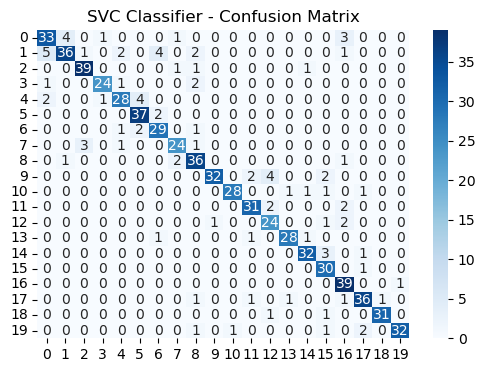

In [44]:
y_scaled_pred = svc_scaled_rbf_model.predict(x_test)
# Metrics
print("--- SVC Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_scaled_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_scaled_pred, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_scaled_pred, average='macro'):.4f}")

# Classification Report
print("classification report:")
print(classification_report(y_test,y_scaled_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_scaled_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SVC Classifier - Confusion Matrix')
plt.show()

# Final Model - svc - rbf

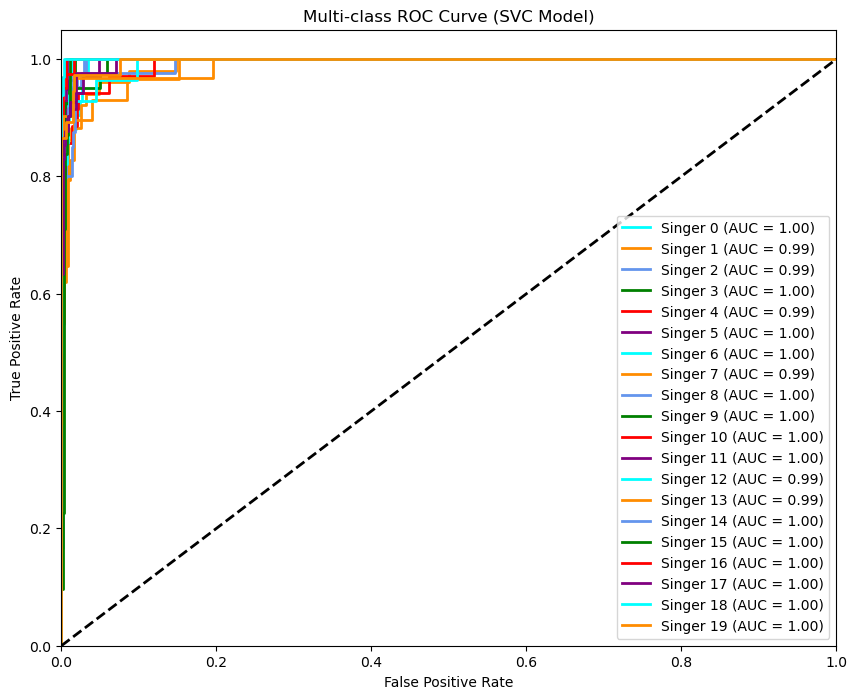

In [45]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle

# Binarize the labels (Required for multi-class ROC)
# Assuming 'y_test' contains your singer labels
classes = sorted(list(set(y_test)))
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Get probability scores from your model
y_score = svc_scaled_rbf_model.predict_proba(x_test)

# Plotting
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'Singer {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (SVC Model)')
plt.legend(loc="lower right")
plt.show()

In [47]:
# Checking overfitting
y_train_pred = svc_scaled_rbf_model.predict(x_train)
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred, average='macro'):.4f}")

Accuracy:  0.9495
Precision: 0.9506
Recall:    0.9493
F1 Score:  0.9497


In [48]:
import joblib

# 1. Save the Label Encoder (to convert numbers back to singer names)
# 'le' is the LabelEncoder you fitted at the top of your notebook
joblib.dump(le, 'label_encoder.pkl')

# 2. Save the SVC Pipeline 
# Because you used make_pipeline(StandardScaler(), SVC()), 
# the scaler is saved automatically inside this object!
joblib.dump(svc_scaled_rbf_model, 'svc_singer_model.pkl')

print("Model and Encoder saved successfully!")

Model and Encoder saved successfully!
